In [1]:
from wrf_tools import WRFProcessor, ERA5DataDownloader
import os


In [2]:
run_period = { 'start_date' : "2025-04-01 00", 'end_date' : "2025-04-01 18" }

setting = "test"

#domain_center = { 'id': 'Mogadishu', 'lat': 2.05, 'lon': 45.32 }

domain_center = {
    'id': 'Bangkok',
    'lat': 13.75,
    'lon': 100.50
}

domain = { 'max_dom': 3, 'parent_grid_ratio' : (1,3,3), 
          'dx' : 18000, 'dy' : 18000, 
          'e_we_ini' : (100, 100, 100),
          'e_sn_ini' : (100, 100, 100) }

paths = {
    'wpsdir': os.environ.get('WPS'),
    'wrfdir': os.environ.get('WRF'),
    'geogdir': os.environ.get('WPS_GEOG'),
    'renaldir': os.path.join(os.environ.get('REANAL'), "era5/"+domain_center['id']+'/'), 
    'namelist_wps' : os.path.join(os.environ.get('WRF_TOOLS'), "namelists",f"{setting}_namelist.wps"),
    'namelist_input': os.path.join(os.environ.get('WRF_TOOLS'), "namelists",f"{setting}_namelist.input")
}
download_dir = paths['renaldir']

#  You can set directly as below if you do not want to use environment variables.
# paths = {
#     'wpsdir': "/Volumes/work/WRF_program/WRF_install/WPS/",
#     'wrfdir': "/Volumes/work/WRF_program/WRF_install/WRF_mpi/",
#     'geogdir': "/Volumes/work/WRF_program/WPS_GEOG",
#     'renaldir': "/Volumes/work/WRF_program/era5/"+domain_center['id']+'/',
#     'namelist_wps' : "/Volumes/work/WRF_program/WRF_install/WPS//namelist.wps",
#     'namelist_input': "/Volumes/work/WRF_program/WRF_install/WRF_mpi/run/namelist.input"
# }

# download_dir = f"/Volumes/work/WRF_program/era5/{domain_center['id']}/"

In [4]:
downloader = ERA5DataDownloader(run_period, domain_center, domain, download_dir)
downloader.download_data()

2026-03-23 16:19:43,891 INFO Request ID is 2764814b-4dc0-47b0-aab7-a9e0dcb90837
2026-03-23 16:19:44,180 INFO status has been updated to accepted
2026-03-23 16:19:58,786 INFO status has been updated to successful
2026-03-23 16:20:24,574 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-03-23 16:20:24,576 INFO Request ID is 1e2f1ab7-6659-43ac-88bc-3a16b54fc990
2026-03-23 16:20:25,835 INFO status has been updated to accepted
2026-03-23 16:20:41,638 INFO status has been updated to successful
                                                                                  

Completed data download for 2025-04-01.


In [3]:
base_dir = os.environ.get('SIMULATION')
run_dir = os.path.join(base_dir, 'Run_WRF', domain_center['id'], setting)

wrf_processor = WRFProcessor(run_period, domain_center, domain, paths, run_dir, num_process=4, run_wrf=False, other_GEOTBL=None, force=None)
wrf_processor.run_wrf()

---low latitude:  13.75
---geogrid done
---ungrib done
---metgrid done
18000.0, 6000.0, 2000.0
---real done


In [9]:
from wrf_tools.ghcn_download_processor import GHCNhProcessor
import xarray as xr

In [11]:
geo_em = os.path.join(run_dir, "geo_em.d03.nc")
ds = xr.open_dataset(geo_em)
area = [
    float(ds['XLAT_C'].values[0][0, 0]),
    float(ds['XLAT_C'].values[0][-1, 0]),
    float(ds['XLONG_C'].values[0][0, 0]),
    float(ds['XLONG_C'].values[0][0, -1]),
]
start_year, end_year = int(run_period['start_date'][:4]), int(run_period['end_date'][:4])

Found 17 stations. Starting download and processing...

--- Processing station: THA00484777 ---
Downloading: https://www.ncei.noaa.gov/oa/global-historical-climatology-network/hourly/access/by-year/2025/psv/GHCNh_THA00484777_2025.psv
Error for station THA00484777, year 2025: HTTP Error 404: Not Found

--- Processing station: THI0000VTBD ---
File GHCNh_THI0000VTBD_2025.psv already exists


/home/yuasa/WRF_tools/wrf_tools/ghcn_download_processor.py:141: DtypeWarning: Columns (54,56,58,61,77,80,82,179,182,184,185,188,190,204,206,208,210,212,214,276,278,280,282,284,286,294,296,298,306,308,310,318,320,322) have mixed types. Specify dtype option on import or set low_memory=False.
  d = pd.read_csv(fil, index_col=2, parse_dates=True, sep="|")



--- Processing station: THM00048415 ---
File GHCNh_THM00048415_2025.psv already exists


/home/yuasa/WRF_tools/wrf_tools/ghcn_download_processor.py:141: DtypeWarning: Columns (54,56,58,61,156,158,160,192,194,196,276,278,280,282,284,286,294,296,298,306,308,310,318,320,322) have mixed types. Specify dtype option on import or set low_memory=False.
  d = pd.read_csv(fil, index_col=2, parse_dates=True, sep="|")



--- Processing station: THM00048419 ---
File GHCNh_THM00048419_2025.psv already exists


...


--- Processing station: THM00048461 ---
File GHCNh_THM00048461_2025.psv already exists


/home/yuasa/WRF_tools/wrf_tools/ghcn_download_processor.py:141: DtypeWarning: Columns (54,56,58,67,276,278,280,282,284,286,294,296,298,308,310,318,320,322) have mixed types. Specify dtype option on import or set low_memory=False.
  d = pd.read_csv(fil, index_col=2, parse_dates=True, sep="|")



--- Processing station: THM00048464 ---
File GHCNh_THM00048464_2025.psv already exists


/home/yuasa/WRF_tools/wrf_tools/ghcn_download_processor.py:141: DtypeWarning: Columns (61,306) have mixed types. Specify dtype option on import or set low_memory=False.
  d = pd.read_csv(fil, index_col=2, parse_dates=True, sep="|")



All results have been saved successfully.
Saved : /mnt/work/yuasa/simulation/GHCN_data/summaries/station_location_map.png


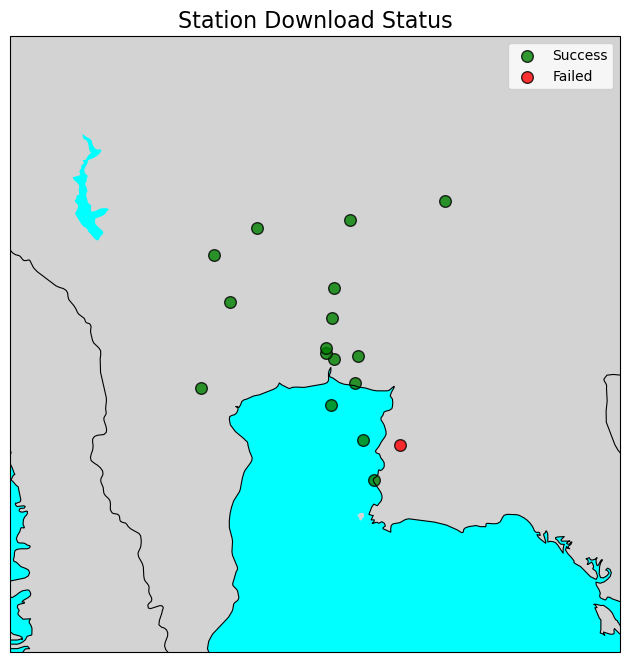

In [12]:
processor = GHCNhProcessor(
    start_year=start_year,
    end_year=end_year,
    area=area,
    output_dir=os.path.join(os.environ.get('SIMULATION'), "GHCN_data")
)

processor.download_data()                    # Run data download and processing
processor.plot_station_locations() # Plot station locations with categories

Saved heatmap to: /mnt/work/yuasa/simulation/GHCN_data/summaries/availability_heatmap_THI0000VTBD.png
Saved heatmap to: /mnt/work/yuasa/simulation/GHCN_data/summaries/availability_heatmap_THM00048415.png
Saved heatmap to: /mnt/work/yuasa/simulation/GHCN_data/summaries/availability_heatmap_THM00048419.png
Saved heatmap to: /mnt/work/yuasa/simulation/GHCN_data/summaries/availability_heatmap_THM00048420.png
Saved heatmap to: /mnt/work/yuasa/simulation/GHCN_data/summaries/availability_heatmap_THM00048425.png
Saved heatmap to: /mnt/work/yuasa/simulation/GHCN_data/summaries/availability_heatmap_THM00048427.png
Saved heatmap to: /mnt/work/yuasa/simulation/GHCN_data/summaries/availability_heatmap_THM00048429.png
Saved heatmap to: /mnt/work/yuasa/simulation/GHCN_data/summaries/availability_heatmap_THM00048435.png
Saved heatmap to: /mnt/work/yuasa/simulation/GHCN_data/summaries/availability_heatmap_THM00048451.png
Saved heatmap to: /mnt/work/yuasa/simulation/GHCN_data/summaries/availability_heat

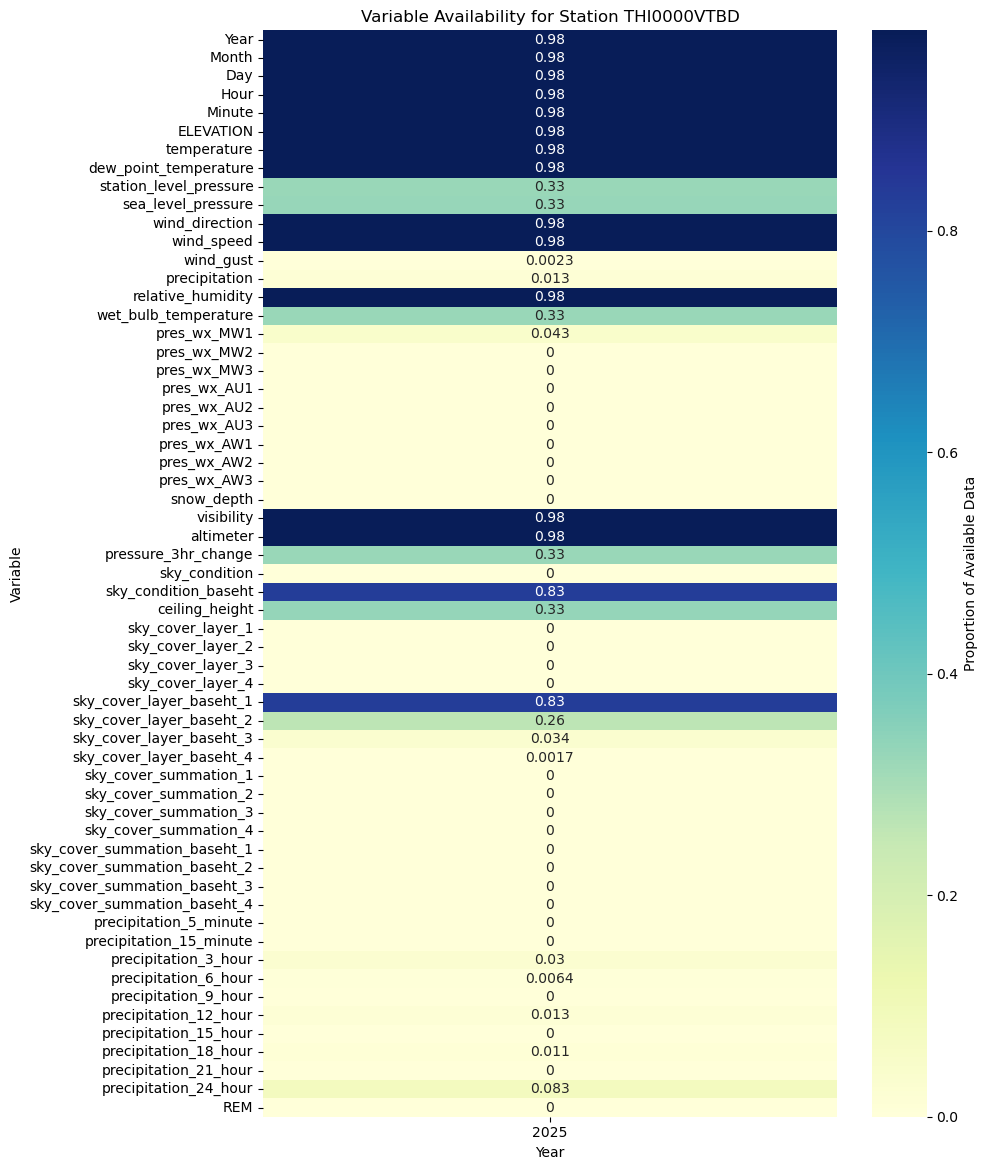

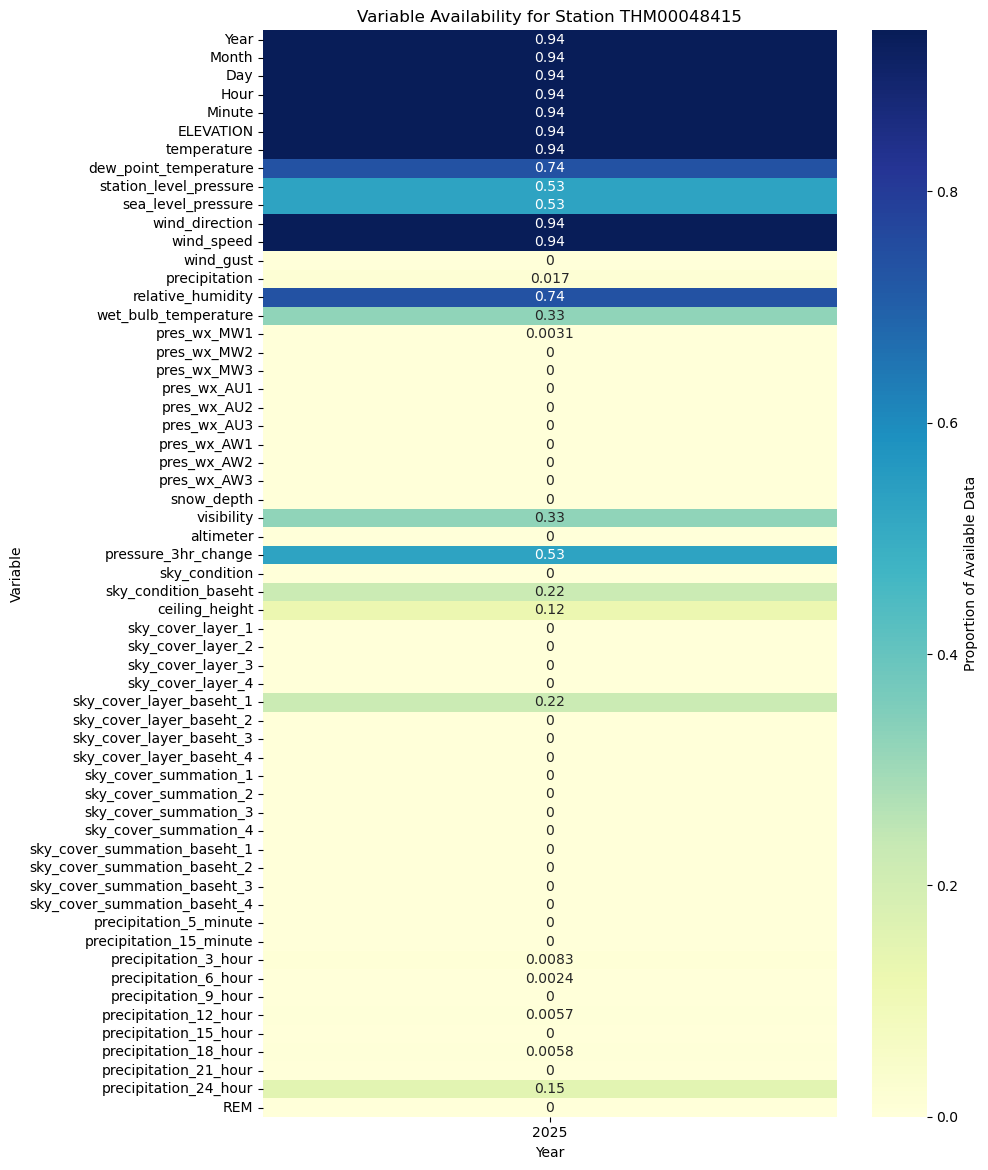

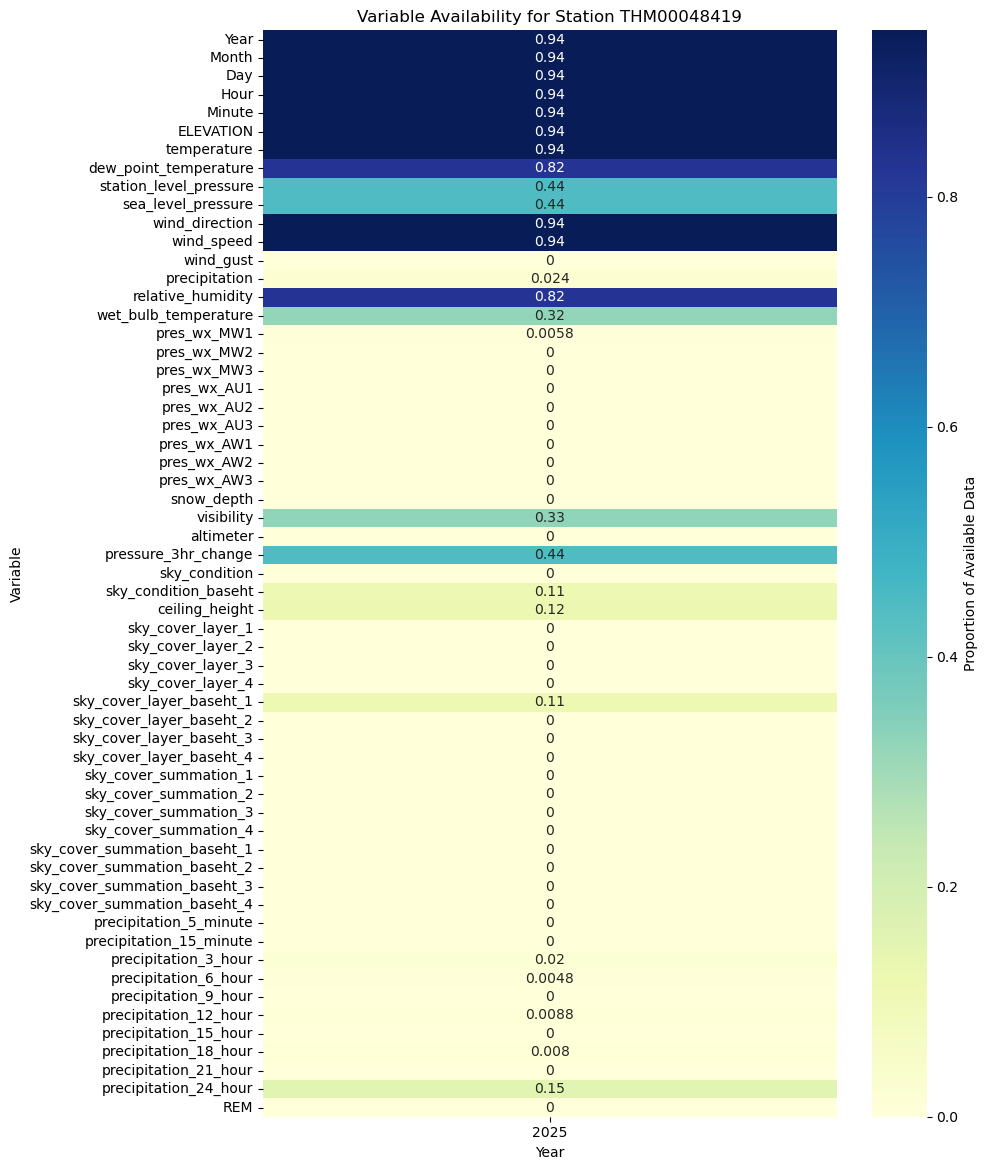

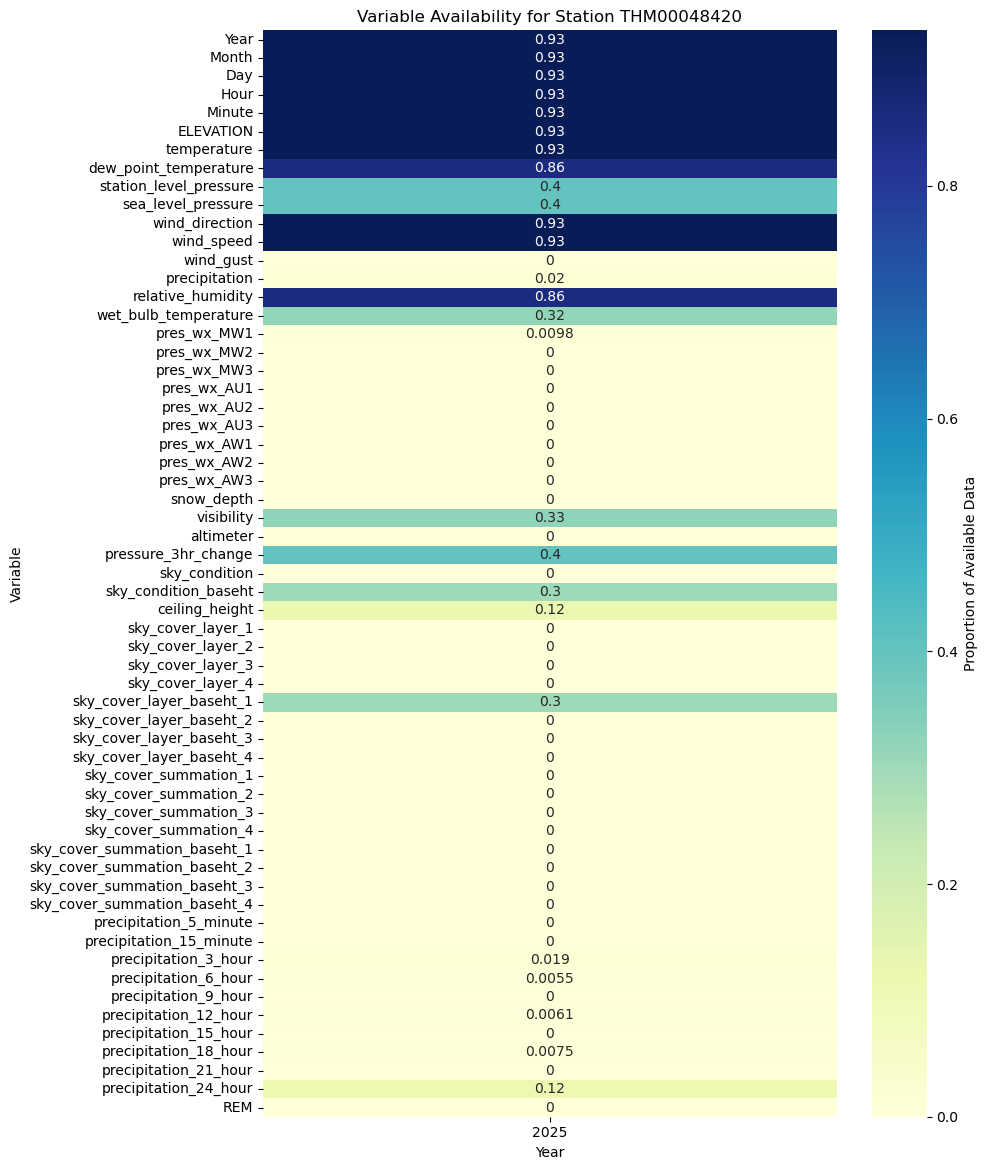

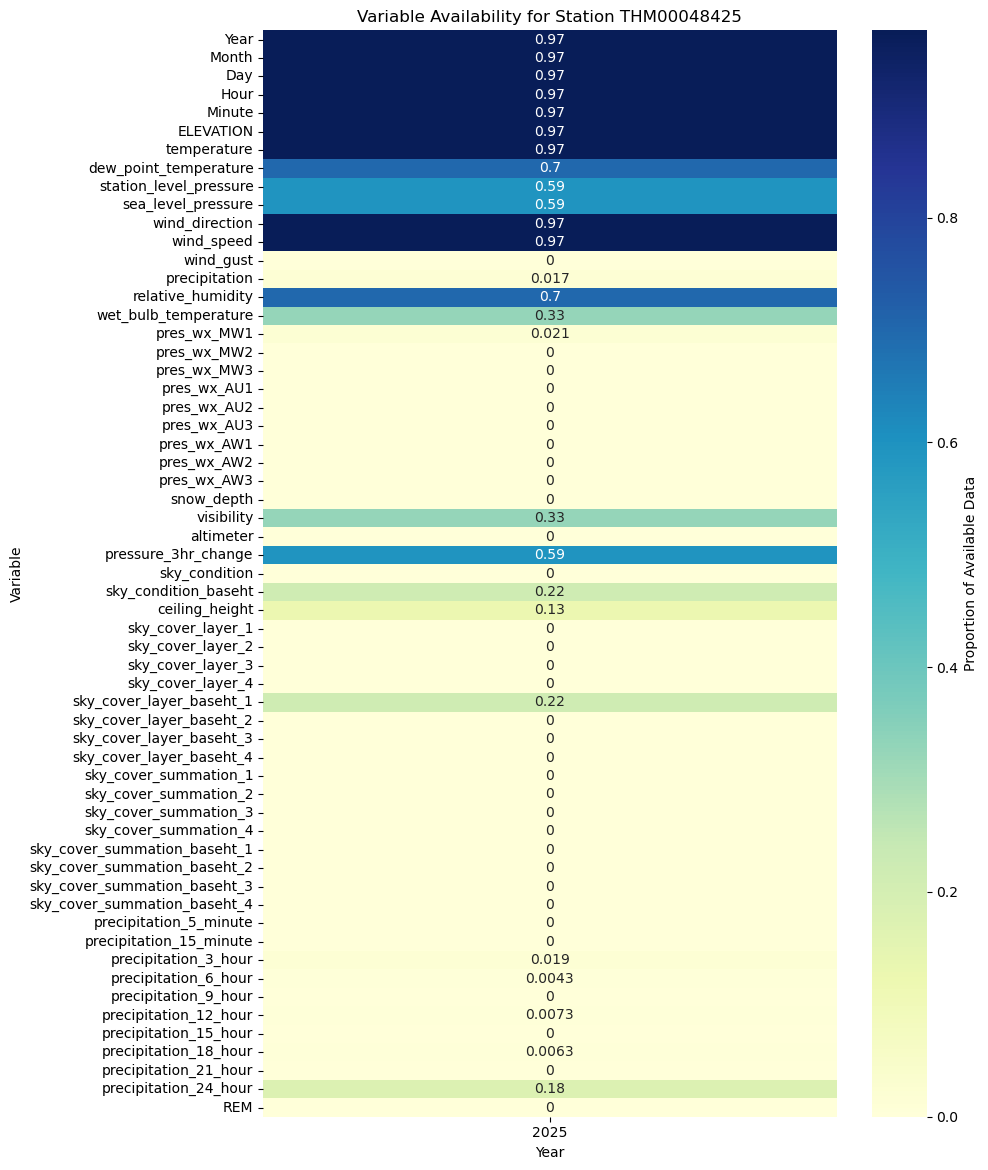

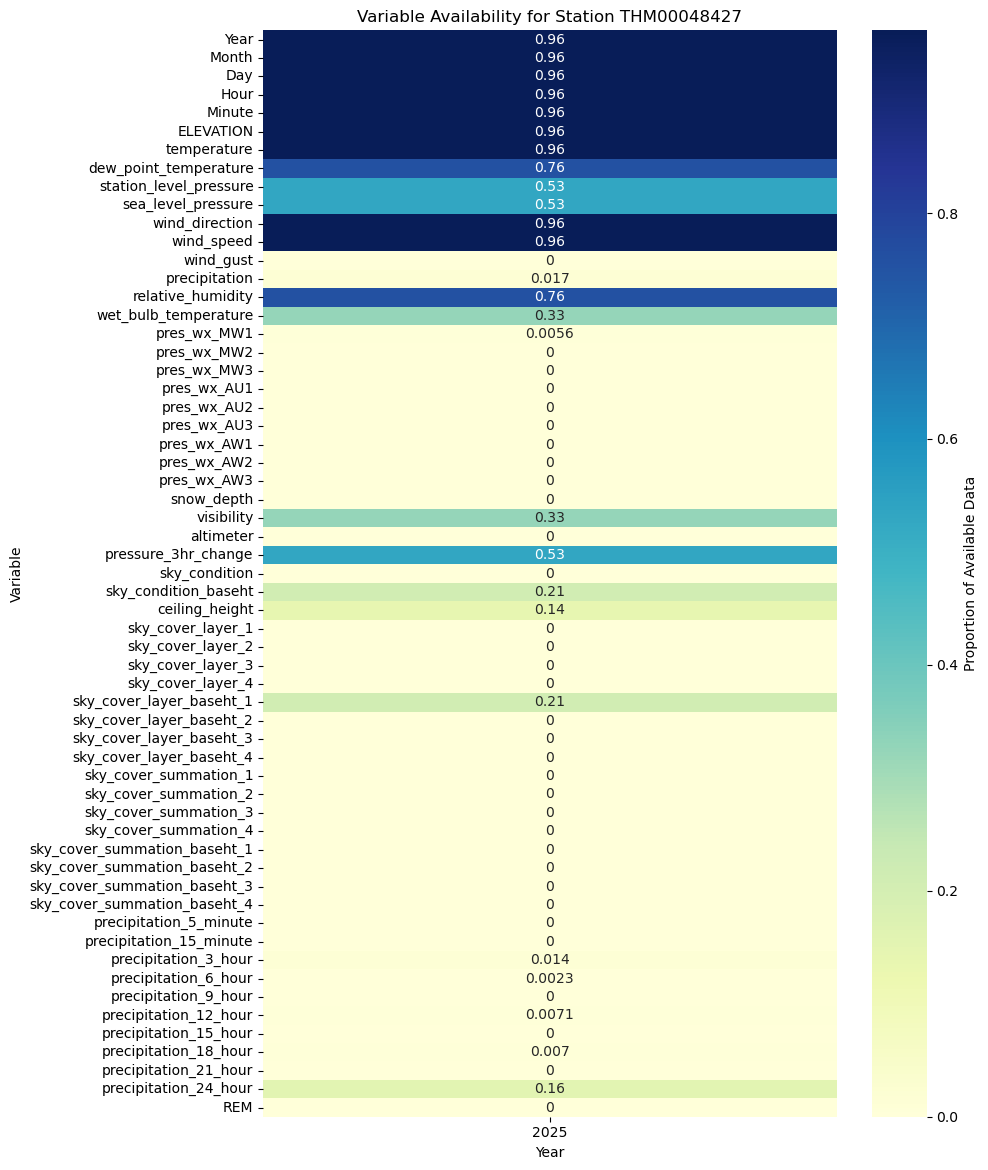

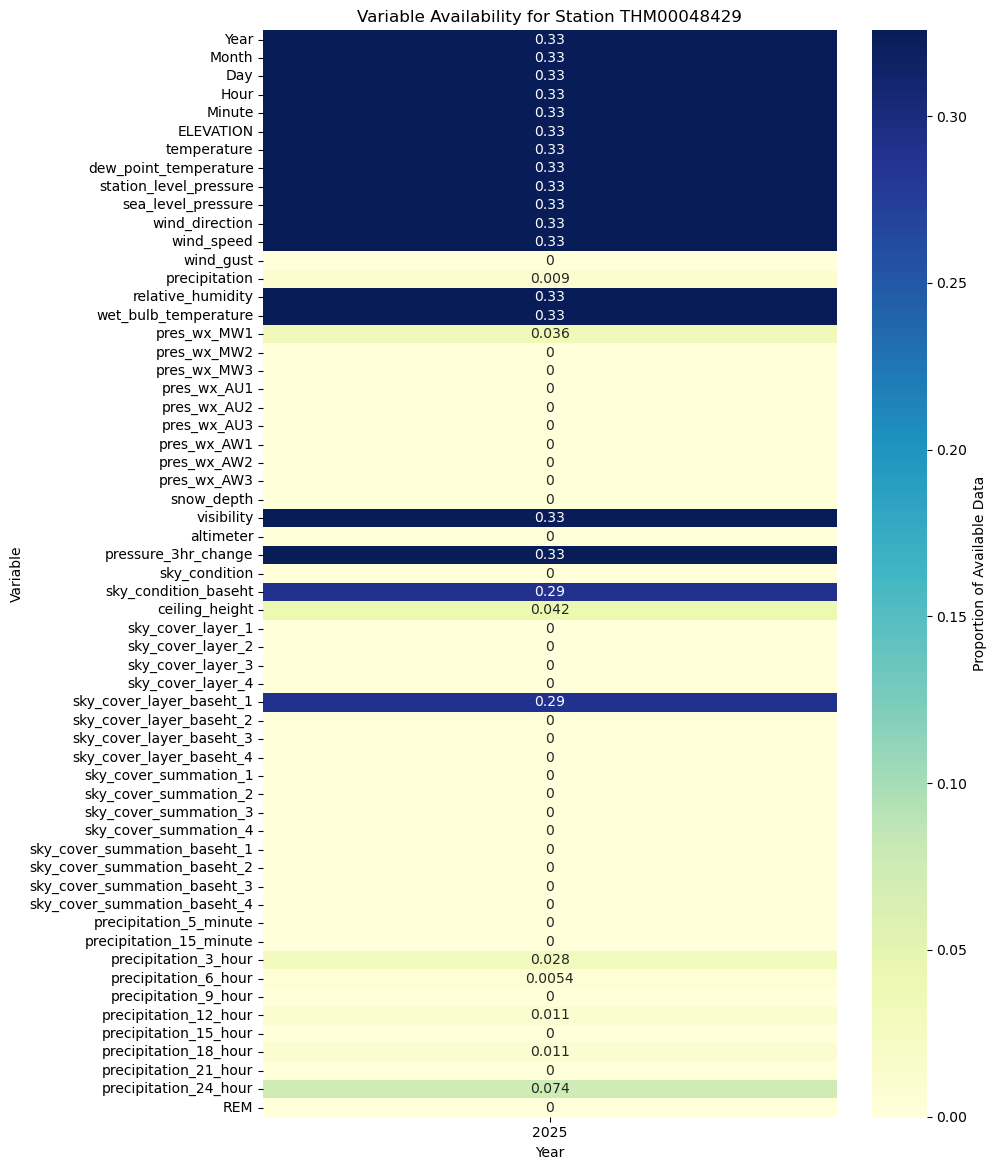

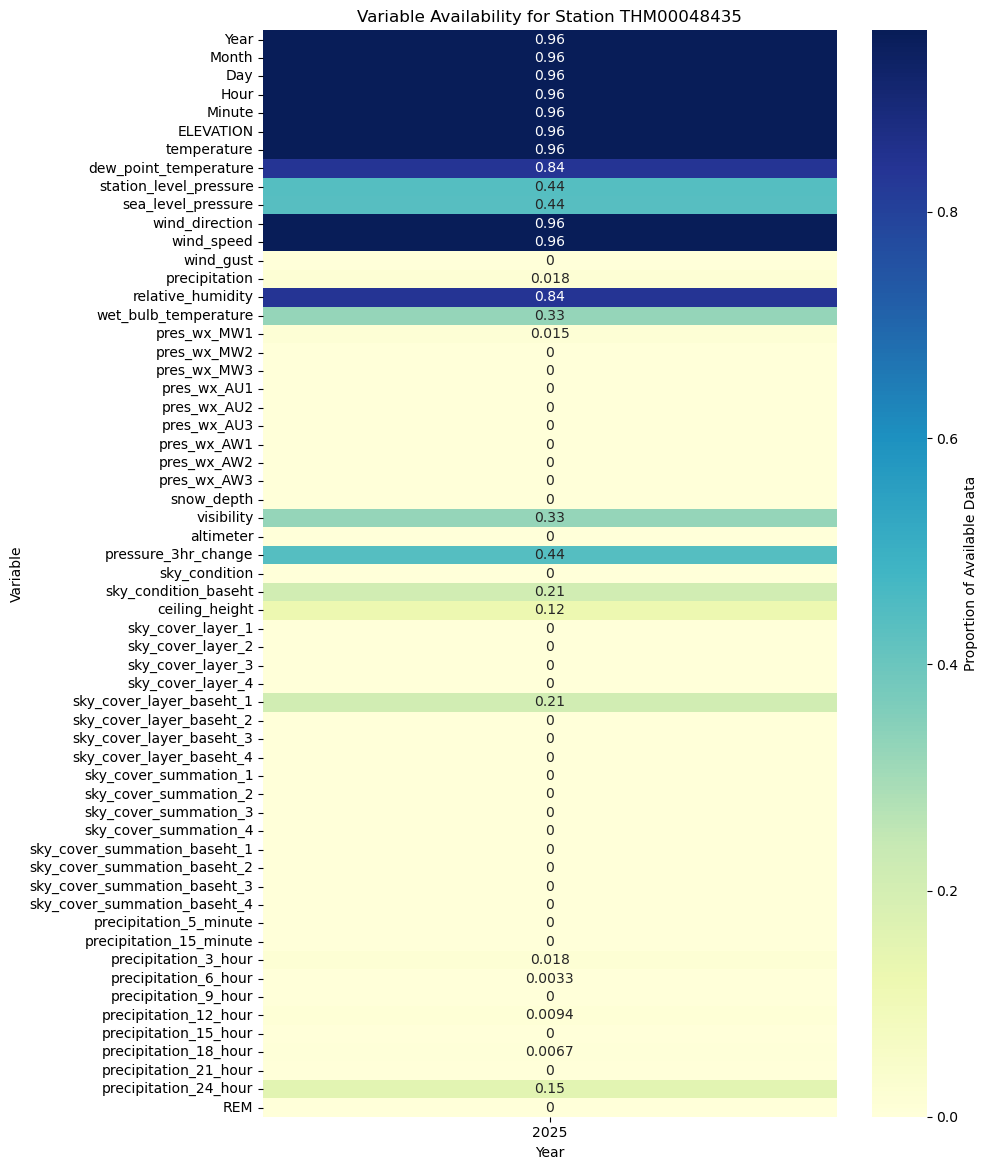

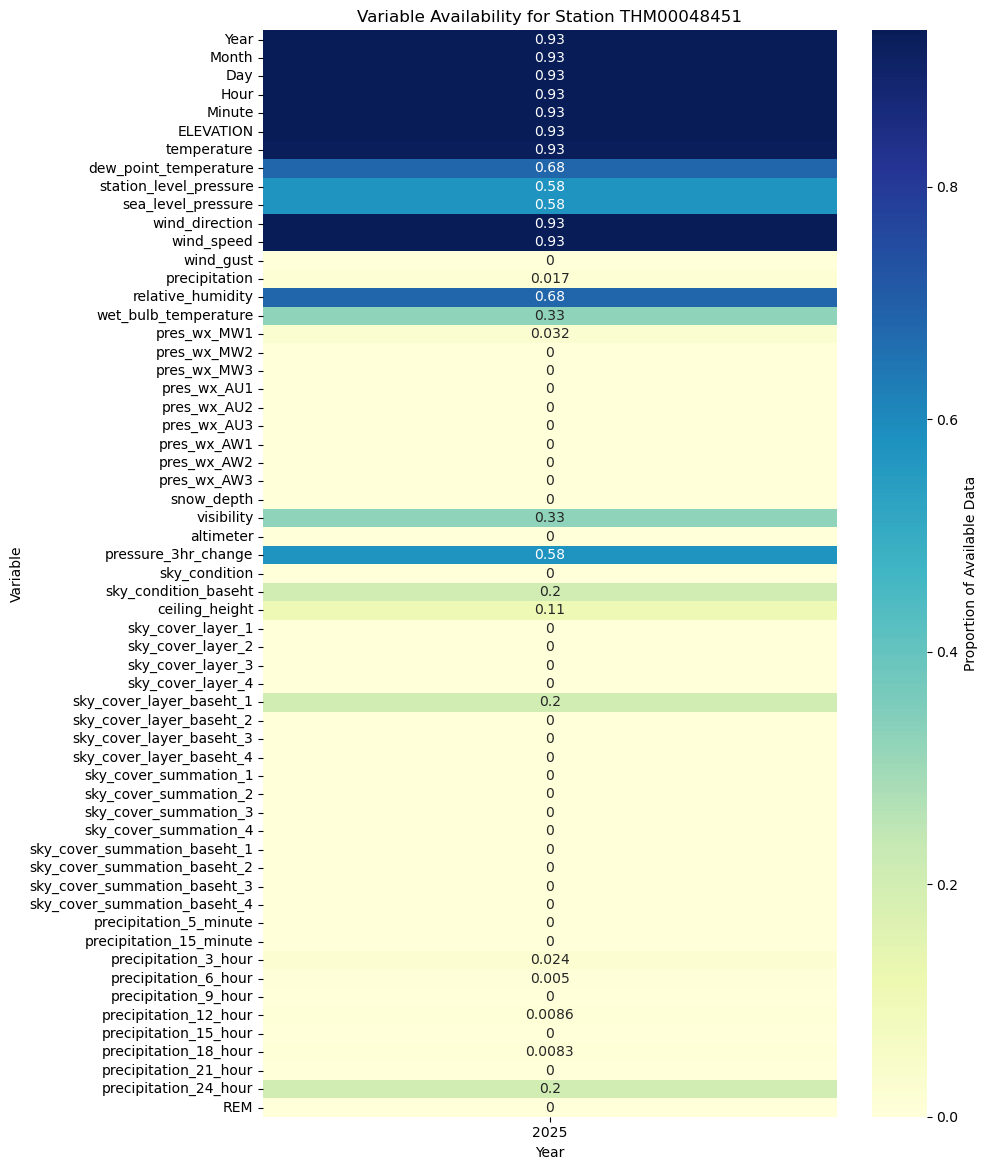

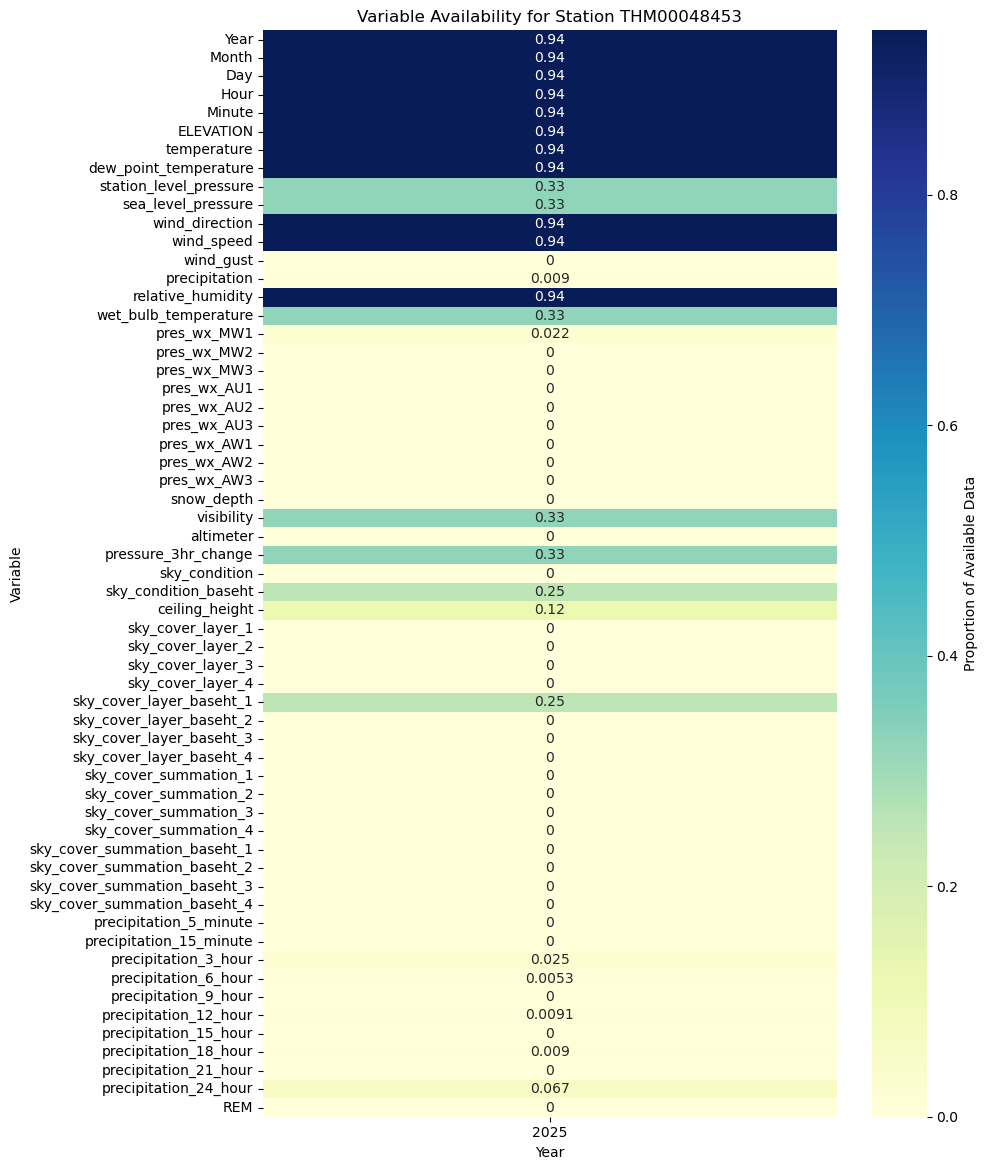

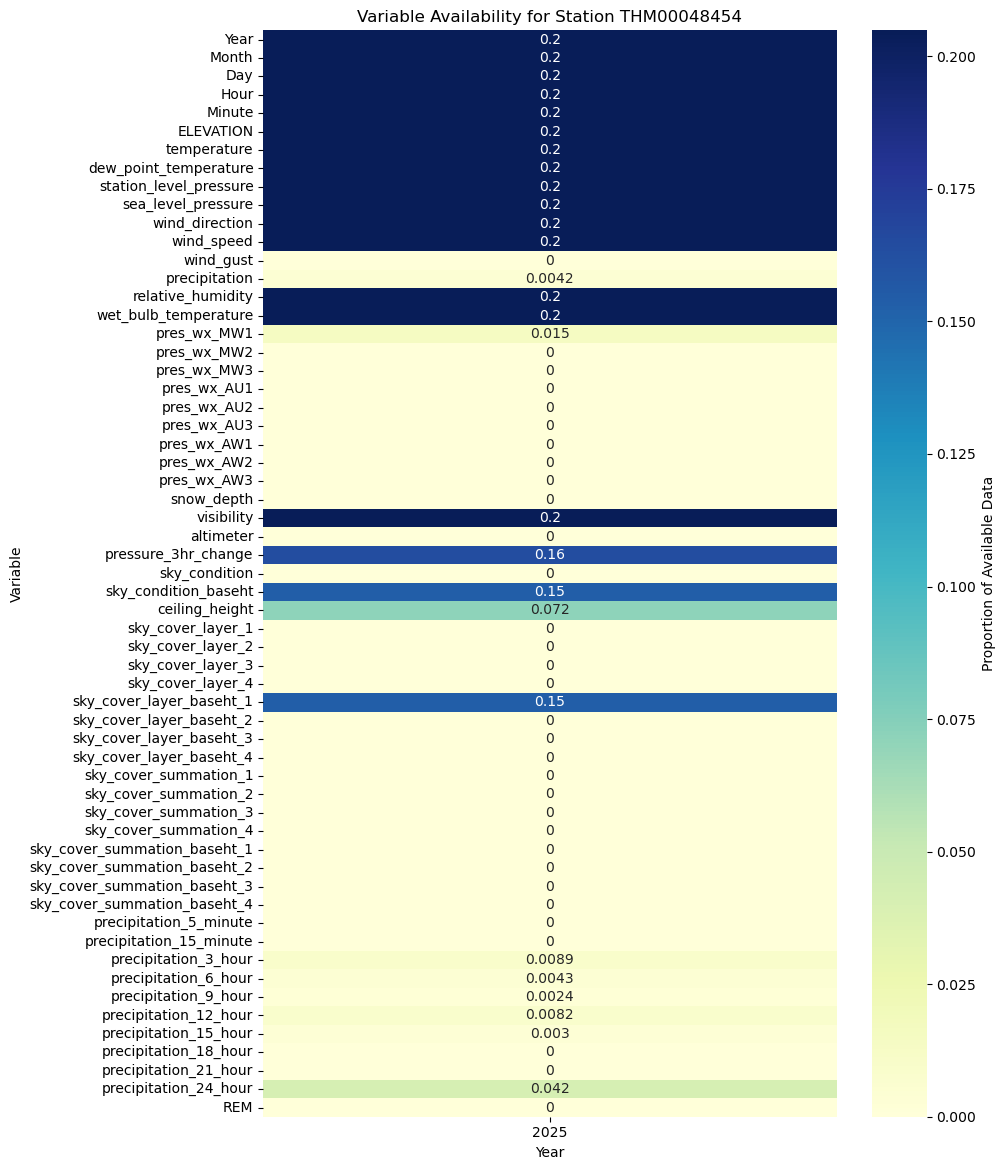

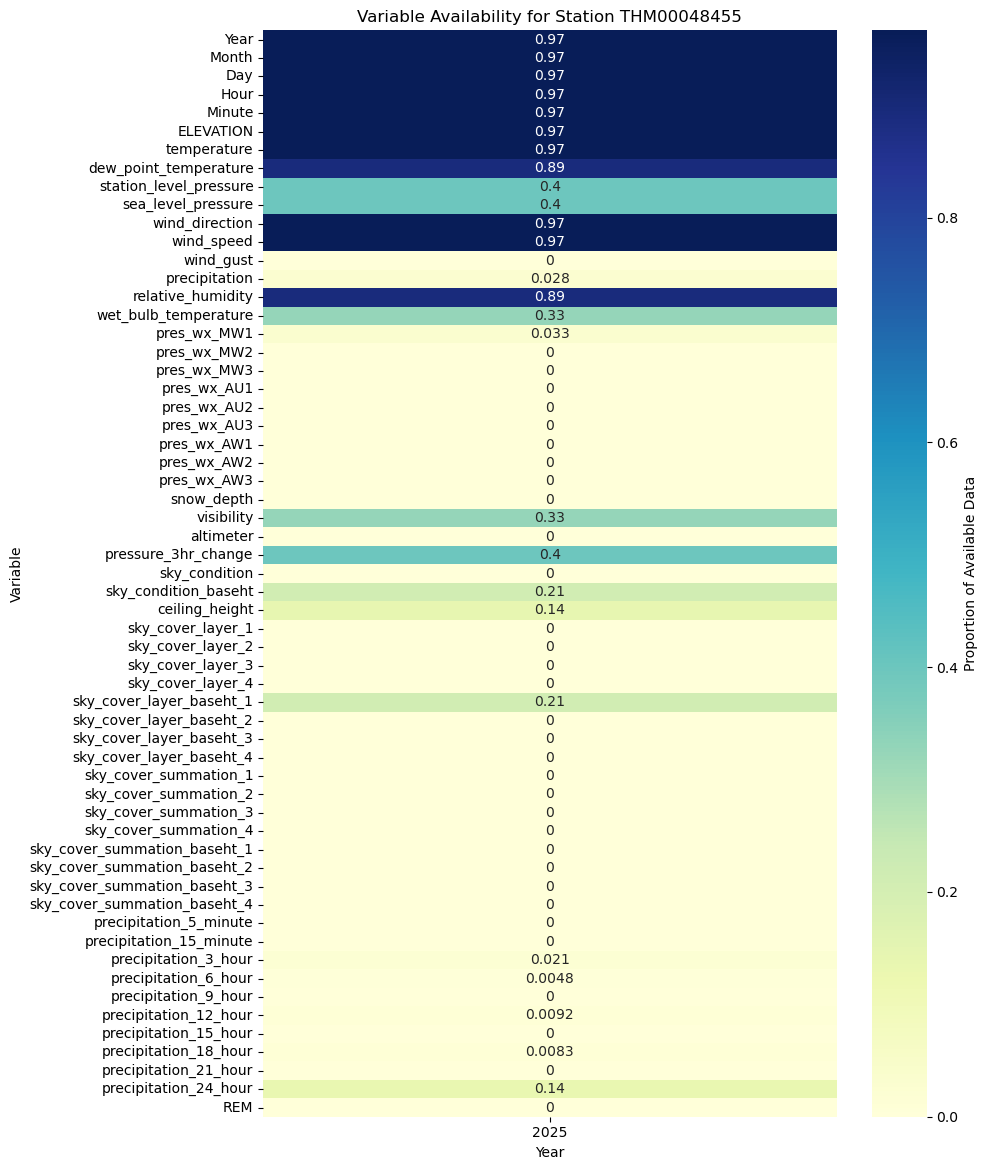

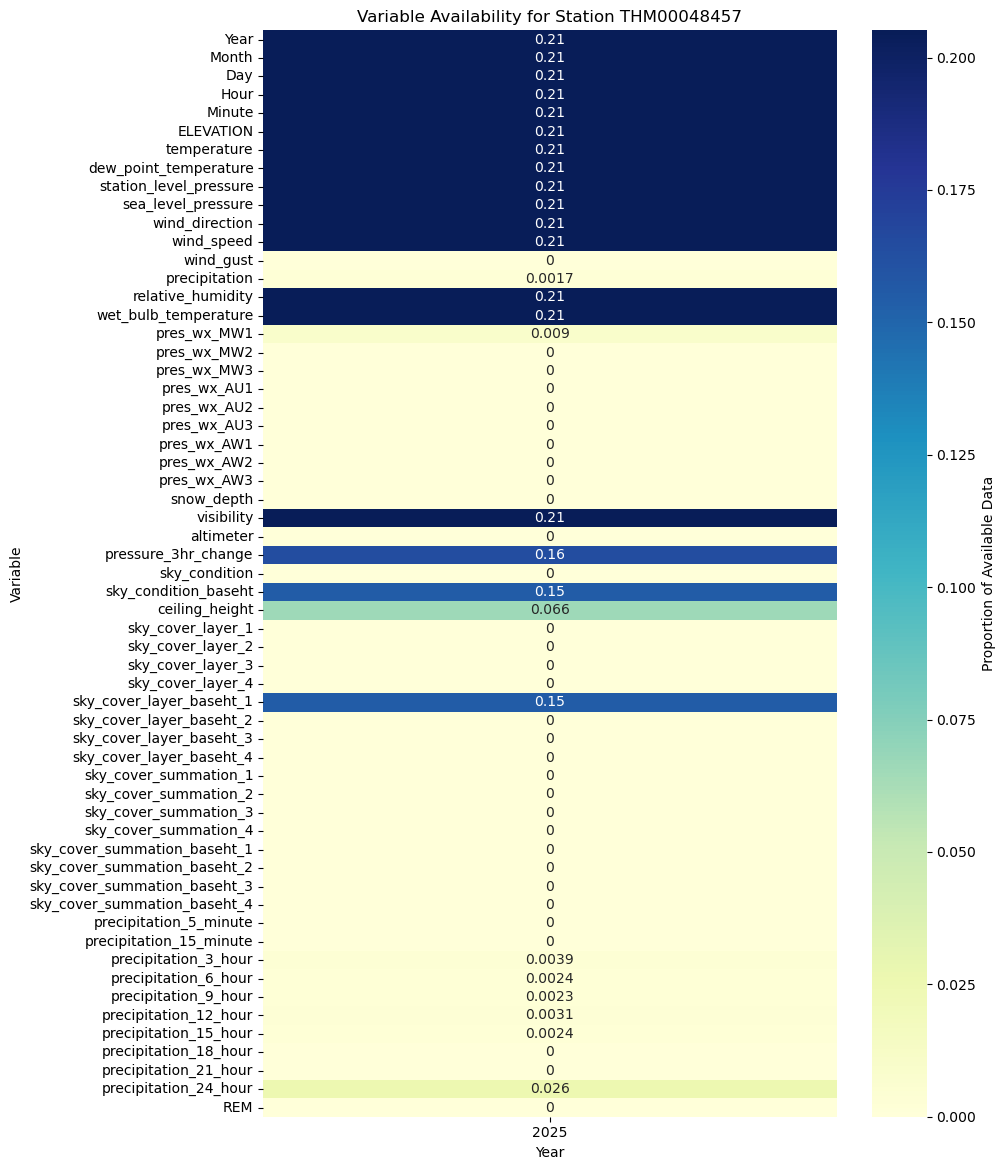

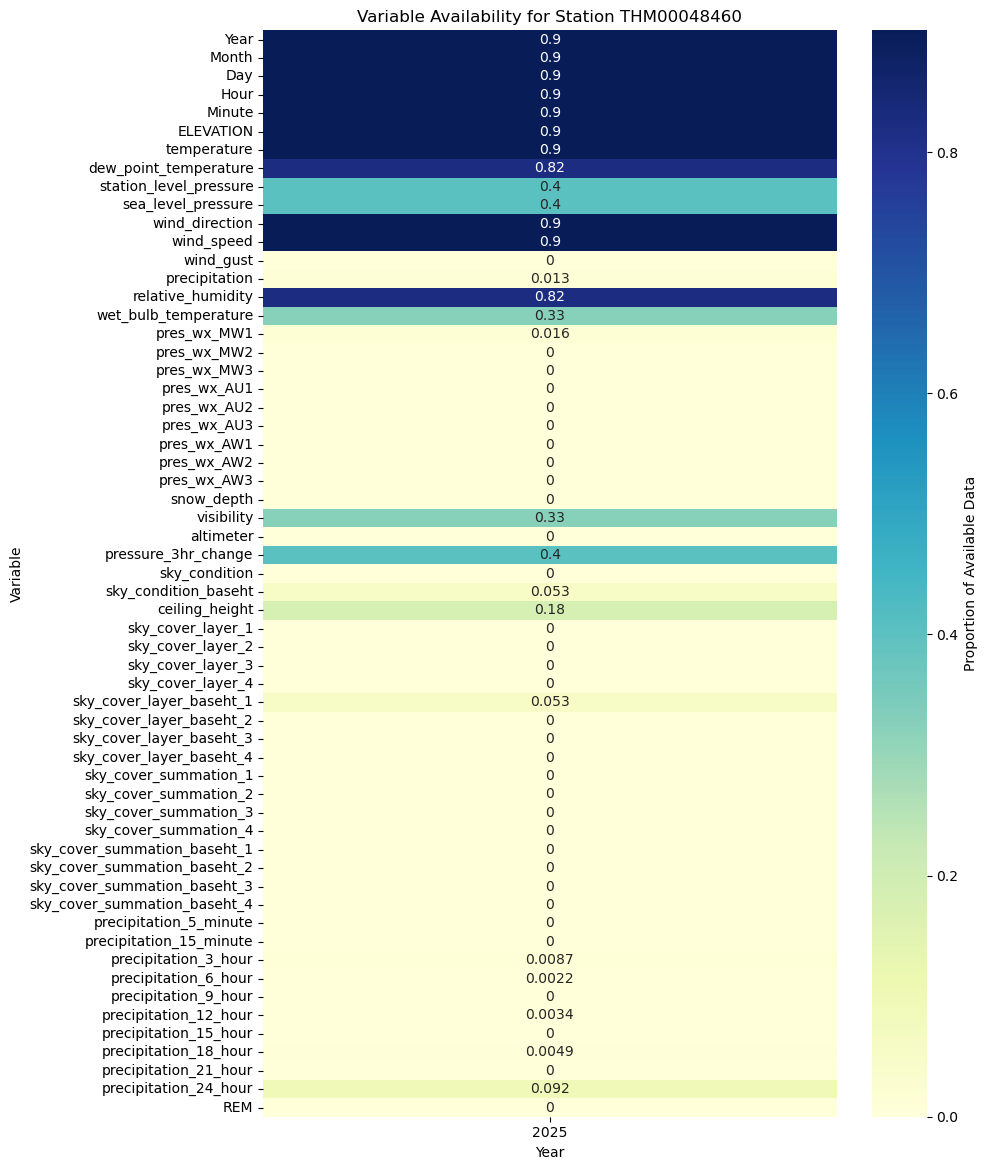

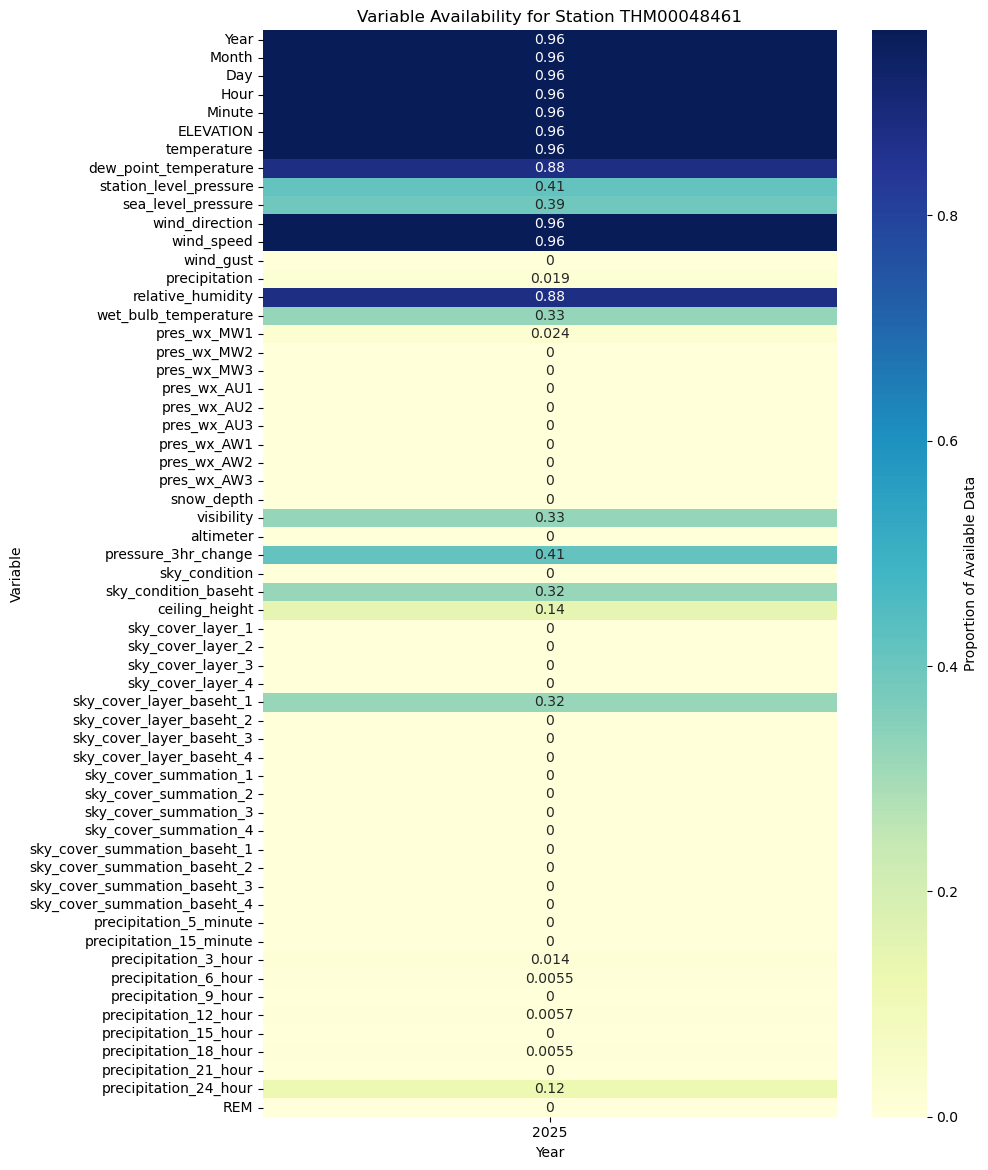

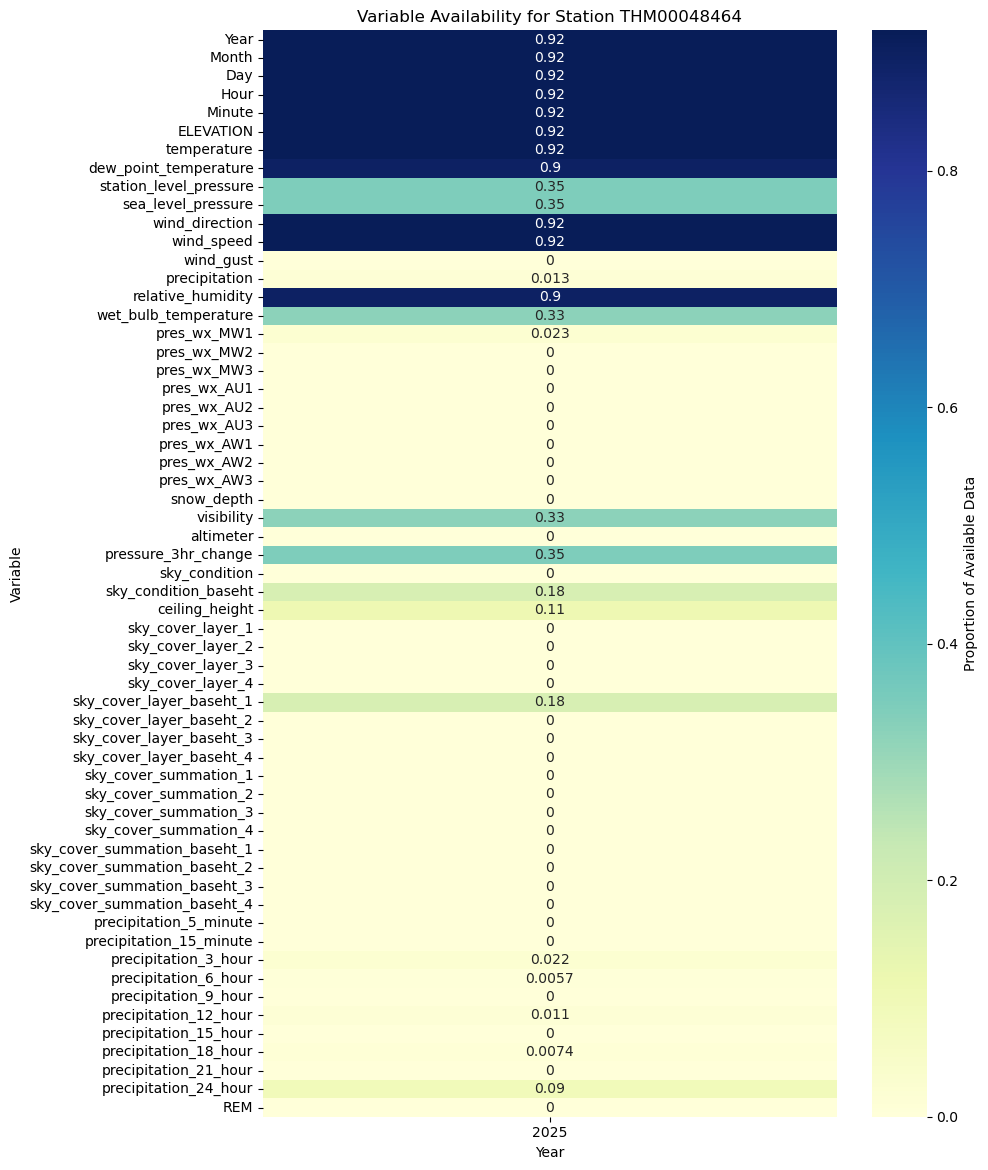

In [13]:
processor.plot_availability_heatmaps()  # Plot heatmaps (if seaborn is available)